In [1]:
#Import Packages
import numpy as np #importing numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics 
from sklearn.preprocessing import MultiLabelBinarizer

## Load Data

In [215]:
dataframe = pd.read_csv("1744728433145A.csv") #Read in data, which is the output file from the crossmatch between ASAS and Gaia
dataframe.drop_duplicates(subset=['ASAS'],keep = 'first') #Drops duplicates in the crossmatch between ASAS, keeping the Gaia object closest to the target coordinates
#dataset has 9652 objects
Vardata = dataframe[['Class','Plx','FG','Gmag','FBP','BPmag','FRP','RPmag','BP-RP','BP-G','G-RP','Teff']] #create table using only relevant columns
Vardata = Vardata.dropna()#drop all NaN values. Remaining table has 4185 objects.

In [216]:
Vardata['GAbsMag'] = Vardata['Gmag'] - 5*np.log10(1/(Vardata['Plx'])) + 5 #Feature engineer Absolute magnitude feature

C:\Users\Caden Burkhardt\.conda\envs\astro-416\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


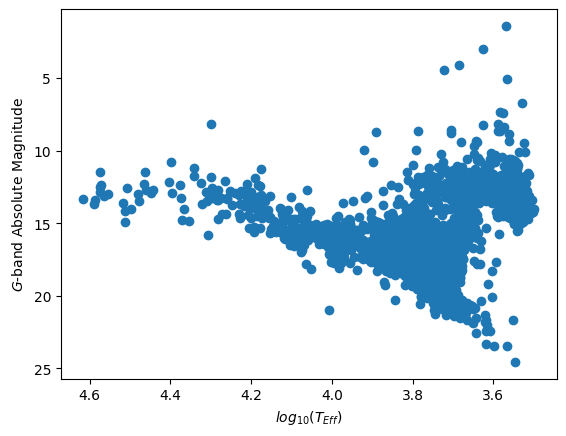

In [217]:
plt.scatter(np.log10(Vardata['Teff']),Vardata['GAbsMag'])
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()
plt.xlabel('$log_{10}(T_{Eff})$')
plt.ylabel('$G$-band Absolute Magnitude');

In [218]:
X = Vardata.iloc[:,1:] #datapoints
y = y_raw = Vardata.iloc[:, :1]['Class'] #labels

In [219]:
len(pd.unique(y))#number of unique labels

191

## Initial Results

### Initial Decision Tree

In [220]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.15, random_state=0) #split data set into 85% training and 15% testing data
model = DecisionTreeClassifier(random_state = 3) #use a decision tree
model.fit(Xtrain, ytrain) #fiting the model to the training data

ypred = model.predict(Xtest) #running the model on the test data
print(metrics.accuracy_score(ytest, ypred)) #evaluating how the model using the accuracy metric

0.3343949044585987


Issue with the initial decision tree is that there are too many possible labels due to the multiple possible classifcations for many objects. We attempt to solve this with multi-label classification

possible classess 
DSCT(Delta Scuti), 
RRC(RR Lyrae ), 
RRAB(RR Lyrae ), 
DCEP_FU(Delta Cep), 
DCEP_FO(Delta Cep), 
CW(W Vir stars), 
ACV(Alpha2 Canum Venaticorum variable), 
BCEP(Beta Cephei)
MISC

### Multilabel Classification

In [221]:
#preprocess labels for multi-label classification, split multiple labels into a list of multiple labels
#This section of code was developed with the use of AI assistance
import re #Real Expression Library used to manipulate strings very easily

#define a label splitting fuction we will apply to all of our labels
def clean_and_split(label_str): 
    # Remove everything from ":" onward (including the colon) by replacing it with nothing
    cleaned = re.sub(r':[^\s/=]*', '', label_str)
    # Split on both '/' and '='
    return re.split(r'[=/]', cleaned) #splits the labels into two labels at either = or /

y_multi = [clean_and_split(label) for label in y_raw]# applying the label splitting function to all of labels

In [222]:
from sklearn.preprocessing import MultiLabelBinarizer #package used to convert list of labels into a binary matrix 

mlb = MultiLabelBinarizer() #using the multiLabelBinarizer
binary_labels = mlb.fit_transform(y_multi) #applying the multiLabelBinarizer to the data

binary_df = pd.DataFrame(binary_labels, columns=mlb.classes_)# convert binary matrix labels into a pandas dataframe

In [223]:
#split data into testing and training dataset with the new labels
Xtrain, Xtest, ytrain_multi, ytest_multi = train_test_split(X, binary_df, test_size=0.15, random_state=0) 

In [224]:
from sklearn.multioutput import MultiOutputClassifier

In [225]:
model = MultiOutputClassifier(DecisionTreeClassifier(random_state = 3))

# Fit the model
model.fit(Xtrain, ytrain_multi)

# Predict on test data
y_true = np.array(ytest_multi, dtype=bool)
y_pred = model.predict(Xtest)
y_pred = np.array(y_pred, dtype=bool)

# define a function do determine our accuracy if any of the predicted labels match their correct labels, as opposed to needing all labels to match
def any_label_match(y_true, y_pred):
    return np.any(y_true & y_pred, axis=1)  # axis=1 applies it row-wise

match_mask = any_label_match(y_true, y_pred)
accuracy_any = np.mean(match_mask)

print(f"Accuracy (any correct label match): {accuracy_any:.3f}")

Accuracy (any correct label match): 0.675


In [226]:
len(binary_df.columns)

25

## Final Results

### Additional Preprocessing Labels

#### Additional Feature Engineering

In [227]:
#Update absolute magnitude feature engineering with extinction value
Vardata = dataframe[['Class','Plx','FG','Gmag','FBP','BPmag','FRP','RPmag','BP-RP','BP-G','G-RP','Teff','AG']] #create table using only relevant columns
Vardata['GAbsMag'] = Vardata['Gmag'] - Vardata['AG']- 5*np.log10(1/(Vardata['Plx'])) + 5 #Feature engineer Absolute magnitude feature
#Vardata = Vardata.drop('Plx',axis = 1)
#Vardata = Vardata.drop('AG',axis = 1)

C:\Users\Caden Burkhardt\.conda\envs\astro-416\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\Caden Burkhardt\AppData\Local\Temp\ipykernel_38348\2483271270.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Vardata['GAbsMag'] = Vardata['Gmag'] - Vardata['AG']- 5*np.log10(1/(Vardata['Plx'])) + 5 #Feature engineer Absolute magnitude feature


#### Negative Parallax

In [228]:
#negative parallax values when passed into the logarithem used to calculate absolute magnitude break and return Nan
#by removing NaNs again, we remove all stars with negative parallax values, which are unphysical and those without absolute magnitude values
Vardata = Vardata.dropna()

### Rerun Decision TreeModel with new Features

In [229]:
X = Vardata.iloc[:,1:] #datapoints
y = y_raw = Vardata.iloc[:, :1]['Class'] #labels
y_multi = [clean_and_split(label) for label in y_raw]# applying the label splitting function to all of labels

#### Consolodating Labels

In [230]:
#This section of code was developed with the use of AI assistance

label_map = {
    '':'DCEP', #single empty label, which is a relic from how we split the labels, we consolodate with cephieds since there is only one and it is already labeled as a cephied
    'DCEP-FU': 'DCEP',# Consolodate Cephieds
    'DCEP-FO': 'DCEP',# Consolodate Cephieds 
    'CW-FU': 'CW', #Consolodate W Vir stars
    'CW-FO': 'CW', #Consolodate W Vir stars
    'DSCTr': 'DSCT', #Consolodate Delta Scuti Stars
    'DSCTr': 'DSCT', #Consolodate Delta Scuti Stars
    'EC': 'E', #Consolodate Eclipsing Binaries
    'ED': 'E', #Consolodate Eclipsing Binaries
    'ESD': 'E', #Consolodate Eclipsing Binaries
    'RRAB': 'RRC', #RR Lyrae Stars   
    'RVA':'MISC', #consolodate very small samples <10 into MISC
    'PULS':'MISC', #consolodate very small samples <10 into MISC
    'NOVA':'MISC', #consolodate very small samples <10 into MISC
    'GCAS':'MISC', #consolodate very small samples <10 into MISC
    'BCEP':'MISC', #consolodate very small samples <10 into MISC
    'ACV':'MISC', #consolodate very small samples <10 into MISC

}

# creates a function to replace labels in split_labels with their consolodated label counterpart
def consolidate_labels(label_list):
    return [label_map.get(label, label) for label in label_list]

y_multi_c = [consolidate_labels(labels) for labels in y_multi]

In [231]:
binary_labels_c = mlb.fit_transform(y_multi_c) #applying the multiLabelBinarizer to the data

binary_df_c = pd.DataFrame(binary_labels_c, columns=mlb.classes_)# convert binary matrix labels into a pandas dataframe

In [232]:
#split data into testing and training dataset with the new labels
Xtrain, Xtest, ytrain_multi, ytest_multi = train_test_split(X, binary_df_c, test_size=0.15, random_state=0) 

In [252]:
model = MultiOutputClassifier(DecisionTreeClassifier(random_state = 3))
#model = DecisionTreeClassifier(random_state = 3,)
# Fit the model
model.fit(Xtrain, ytrain_multi)

# Predict on test data
y_true = np.array(ytest_multi, dtype=bool)
y_pred = model.predict(Xtest)
y_pred = np.array(y_pred, dtype=bool)


match_mask = any_label_match(y_true, y_pred)
accuracy_any = np.mean(match_mask)

print(f"Accuracy (any correct label match): {accuracy_any:.3f}")

Accuracy (any correct label match): 0.791


In [234]:
#This section of code was developed with the use of AI assistance
#speciciflly how to recombine my labels and features into one dataset for plotting
y_binary_df = pd.DataFrame(y_pred[match_mask], columns=mlb.classes_)
dataset = pd.concat([Xtest[match_mask].reset_index(drop=True), y_binary_df.reset_index(drop=True)], axis=1)


In [235]:
#define each variable star population as a mask within the todal dataset of correctly labeled stars
CW = dataset['CW']==True
DCEP = dataset['DCEP']==True
DSCT = dataset['DSCT']==True
E = dataset['E']==True
ELL = dataset['ELL']==True
MIRA = dataset['MIRA']==True
MISC = dataset['MISC']==True
RRC = dataset['RRC']==True
SR = dataset['SR']==True

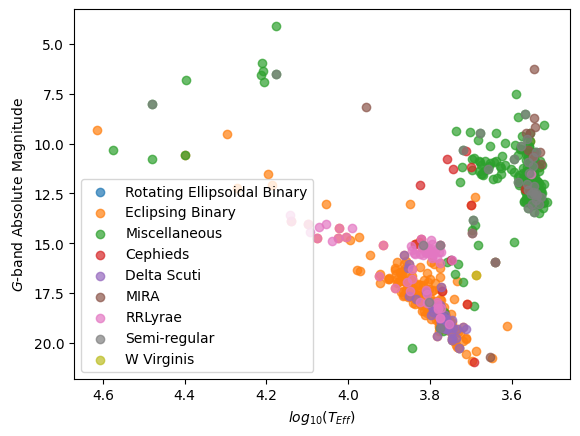

In [250]:
#plot each individual subgroup to see
plt.scatter(np.log10(dataset['Teff'][ELL]),dataset['GAbsMag'][ELL],label = 'Rotating Ellipsoidal Binary',alpha = 0.7)
plt.scatter(np.log10(dataset['Teff'][E]),dataset['GAbsMag'][E],label = 'Eclipsing Binary',alpha = 0.7)
plt.scatter(np.log10(dataset['Teff'][MISC]),dataset['GAbsMag'][MISC],label = 'Miscellaneous',alpha = 0.7)
plt.scatter(np.log10(dataset['Teff'][DCEP]),dataset['GAbsMag'][DCEP],label = 'Cephieds',alpha = 0.7)
plt.scatter(np.log10(dataset['Teff'][DSCT]),dataset['GAbsMag'][DSCT],label = 'Delta Scuti',alpha = 0.7)
plt.scatter(np.log10(dataset['Teff'][MIRA]),dataset['GAbsMag'][MIRA],label = 'MIRA',alpha = 0.7)
plt.scatter(np.log10(dataset['Teff'][RRC]),dataset['GAbsMag'][RRC],label = 'RRLyrae',alpha = 0.7)
plt.scatter(np.log10(dataset['Teff'][SR]),dataset['GAbsMag'][SR],label = 'Semi-regular',alpha = 0.7)
plt.scatter(np.log10(dataset['Teff'][CW]),dataset['GAbsMag'][CW],label = 'W Virginis',alpha = 0.7)


plt.gca().invert_yaxis()
plt.gca().invert_xaxis()
plt.xlabel('$log_{10}(T_{Eff})$')
plt.ylabel('$G$-band Absolute Magnitude')
plt.legend();